# Validación interna no supervisada — Conv1D Autoencoder con datos reales y sintéticos TimeGAN

Este notebook evalúa internamente si los datos sintéticos generados por TimeGAN son útiles para entrenar el detector Conv1D Autoencoder bajo un esquema no supervisado.

La validación externa con etiquetas se realizará después. En esta etapa no se usan labels.

## Escenarios comparados
1. **Real only**: entrenamiento únicamente con ventanas reales normales.
2. **Synthetic only**: entrenamiento únicamente con ventanas sintéticas.
3. **Real + Synthetic**: entrenamiento con mezcla de ventanas reales y sintéticas.

## Métricas internas no supervisadas
- pérdidas de entrenamiento y validación;
- errores de reconstrucción en validación/test reales;
- umbrales `tau` calculados sobre validación real;
- FAR interno sobre test real;
- histogramas, boxplots, ECDF y curvas FAR.


## 1. Imports y configuración


In [1]:
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ["PYTHONHASHSEED"] = str(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [2]:
def find_project_root():
    current = Path.cwd().resolve()
    candidates = [current, current.parent, current.parent.parent]
    for c in candidates:
        if (c / "data" / "clean").exists() or (c / "models").exists():
            return c
    return current.parent

PROJECT_ROOT = find_project_root()
print("PROJECT_ROOT:", PROJECT_ROOT)


PROJECT_ROOT: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation


## 2. Rutas y artefactos de TimeGAN


In [3]:
CLEAN_FOLDER = PROJECT_ROOT / "data" / "clean" / "SWaT.A7_June2020_clean"
TIMEGAN_MODEL_DIR = PROJECT_ROOT / "models" / "timegan" / "conv1d_hybrid_aligned_v21_clean"

SYNTH_CONT_PATH = TIMEGAN_MODEL_DIR / "synth_for_detector.npy"
SYNTH_DISC_RAW_PATH = TIMEGAN_MODEL_DIR / "synth_disc_raw.npy"
SYNTH_DISC_SUMMARY_PATH = TIMEGAN_MODEL_DIR / "synth_disc_summary.csv"
TIMEGAN_CONFIG_PATH = TIMEGAN_MODEL_DIR / "config.json"

print("CLEAN_FOLDER exists:", CLEAN_FOLDER.exists(), CLEAN_FOLDER)
print("TIMEGAN_MODEL_DIR exists:", TIMEGAN_MODEL_DIR.exists(), TIMEGAN_MODEL_DIR)
for p in [SYNTH_CONT_PATH, SYNTH_DISC_RAW_PATH, SYNTH_DISC_SUMMARY_PATH, TIMEGAN_CONFIG_PATH]:
    print(p.name, "->", p.exists())


CLEAN_FOLDER exists: True D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\data\clean\SWaT.A7_June2020_clean
TIMEGAN_MODEL_DIR exists: True D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\timegan\conv1d_hybrid_aligned_v21_clean
synth_for_detector.npy -> True
synth_disc_raw.npy -> True
synth_disc_summary.csv -> True
config.json -> True


## 3. Cargar configuración de TimeGAN


In [4]:
with open(TIMEGAN_CONFIG_PATH, "r") as f:
    timegan_config = json.load(f)

continuous_cols = timegan_config.get("continuous_cols_detector", timegan_config.get("continuous_cols"))
discrete_cols = timegan_config.get("discrete_cols")
WINDOW_SIZE = int(timegan_config.get("window_size", 60))
STRIDE = int(timegan_config.get("stride_timegan", 5))
WARMUP = 120

print("Continuous cols:", len(continuous_cols))
print("Discrete cols:", len(discrete_cols))
print("WINDOW_SIZE:", WINDOW_SIZE)
print("STRIDE:", STRIDE)
print("TimeGAN version:", timegan_config.get("version", "unknown"))


Continuous cols: 23
Discrete cols: 26
WINDOW_SIZE: 60
STRIDE: 5
TimeGAN version: v16


## 4. Cargar y preparar datos reales


In [5]:
file_paths = sorted(CLEAN_FOLDER.glob("*.csv"))
print("Archivos encontrados:", len(file_paths))
for fp in file_paths:
    print(" -", fp.name)
assert len(file_paths) > 0, "No se encontraron CSVs limpios."


Archivos encontrados: 4
 - 22June2020_1.csv
 - 22June2020_2.csv
 - 29June2020_1.csv
 - 29June2020_2.csv


In [6]:
def load_clean_csv(path):
    df = pd.read_csv(path)
    df["t_stamp"] = pd.to_datetime(df["t_stamp"], errors="coerce")
    df = df.sort_values("t_stamp").reset_index(drop=True)
    return df

files = {fp.stem: load_clean_csv(fp) for fp in file_paths}
print("Número de archivos cargados:", len(files))
for name, df in files.items():
    print(name, df.shape)


Número de archivos cargados: 4
22June2020_1 (14400, 61)
22June2020_2 (3600, 61)
29June2020_1 (7201, 61)
29June2020_2 (7201, 61)


In [7]:
common_cols = sorted(set.intersection(*(set(df.columns) for df in files.values())))
files = {name: df[common_cols].copy() for name, df in files.items()}

feature_cols = continuous_cols + discrete_cols
required_cols = ["t_stamp"] + feature_cols
missing_required = [c for c in required_cols if c not in common_cols]
assert not missing_required, f"Faltan columnas requeridas: {missing_required}"

for name in files:
    before = len(files[name])
    files[name] = files[name].dropna(subset=feature_cols, how="all").reset_index(drop=True)
    after = len(files[name])
    if before != after:
        print(f"{name}: filas vacías eliminadas = {before-after}")

files = {name: df.iloc[WARMUP:].reset_index(drop=True) for name, df in files.items()}
for name, df in files.items():
    print(name, df.shape)


29June2020_2: filas vacías eliminadas = 1
22June2020_1 (14280, 61)
22June2020_2 (3480, 61)
29June2020_1 (7081, 61)
29June2020_2 (7080, 61)


In [8]:
def temporal_split(df, train_ratio=0.6, val_ratio=0.2):
    n = len(df)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))
    return df.iloc[:train_end].copy(), df.iloc[train_end:val_end].copy(), df.iloc[val_end:].copy()

split_by_file = {}
for name, df_i in files.items():
    df_base = df_i[["t_stamp"] + feature_cols].copy()
    train_i, val_i, test_i = temporal_split(df_base)
    split_by_file[name] = {"train": train_i, "val": val_i, "test": test_i}
    print(f"{name} | train {train_i.shape} | val {val_i.shape} | test {test_i.shape}")


22June2020_1 | train (8568, 50) | val (2856, 50) | test (2856, 50)
22June2020_2 | train (2088, 50) | val (696, 50) | test (696, 50)
29June2020_1 | train (4248, 50) | val (1416, 50) | test (1417, 50)
29June2020_2 | train (4248, 50) | val (1416, 50) | test (1416, 50)


## 5. Escalado compatible con Conv1D


In [9]:
scaler_cont = StandardScaler()
train_all_cont = pd.concat([split_by_file[n]["train"][continuous_cols] for n in split_by_file], axis=0).reset_index(drop=True)
scaler_cont.fit(train_all_cont)

train_all_disc = pd.concat([split_by_file[n]["train"][discrete_cols] for n in split_by_file], axis=0).reset_index(drop=True)
disc_max = train_all_disc.max().replace(0, 1)

print("Scaler fitted on continuous train:", train_all_cont.shape)
print("disc_max sample:")
print(disc_max.head())


Scaler fitted on continuous train: (19152, 23)
disc_max sample:
MV101.Status    2.0
MV201.Status    2.0
MV301.Status    2.0
MV302.Status    2.0
MV303.Status    2.0
dtype: float64


In [10]:
def scale_real_part(df_part):
    cont_scaled = pd.DataFrame(
        scaler_cont.transform(df_part[continuous_cols]),
        columns=continuous_cols,
        index=df_part.index,
    )
    disc_scaled = df_part[discrete_cols].copy() / disc_max
    combined = pd.concat([cont_scaled.reset_index(drop=True), disc_scaled.reset_index(drop=True)], axis=1)
    return combined[continuous_cols + discrete_cols]

scaled_split_by_file = {}
for name in split_by_file:
    scaled_split_by_file[name] = {}
    for subset in ["train", "val", "test"]:
        scaled_split_by_file[name][subset] = scale_real_part(split_by_file[name][subset])

sample_scaled = next(iter(scaled_split_by_file.values()))["train"]
display(sample_scaled.head())


,AIT201.Pv,AIT202.Pv,AIT203.Pv,AIT501.Pv,AIT502.Pv,AIT503.Pv,AIT504.Pv,DPIT301.Pv,FIT101.Pv,FIT201.Pv,...,P501.Status,P601.Status,P602.Status,UV401.Status,P1_STATE,P2_STATE,P3_STATE,P4_STATE,P5_STATE,P6_STATE
0,-0.706997,-0.448470,-0.306207,1.367272,-0.949844,-0.125324,-0.11854,-0.769799,-0.310613,-0.747078,...,1.0,0.5,0.5,1.0,1.0,1.0,0.010101,1.0,0.571429,1.0
1,-0.706997,-0.446554,-0.306207,1.367272,-0.949844,-0.125324,-0.11854,-0.769799,-0.310613,-0.747078,...,1.0,0.5,0.5,1.0,1.0,1.0,0.010101,1.0,0.571429,1.0
2,-0.706997,-0.446554,-0.306207,1.394345,-0.949844,-0.125324,-0.11854,-0.769799,-0.310613,-0.747078,...,1.0,0.5,0.5,1.0,1.0,1.0,0.010101,1.0,0.571429,1.0
3,-0.706997,-0.442082,-0.306207,1.394345,-0.949844,-0.125324,-0.11854,-0.769799,-0.310613,-0.747078,...,1.0,0.5,0.5,1.0,1.0,1.0,0.010101,1.0,0.571429,1.0
4,-0.706997,-0.441762,-0.306207,1.406840,-0.949844,-0.125324,-0.11854,-0.769799,-0.310613,-0.747078,...,1.0,0.5,0.5,1.0,1.0,1.0,0.010101,1.0,0.571429,1.0


## 6. Construcción de ventanas reales


In [11]:
def create_windows_from_array(arr, window_size=60, stride=5):
    windows = []
    for i in range(0, len(arr) - window_size + 1, stride):
        windows.append(arr[i:i+window_size])
    return np.array(windows, dtype=np.float32)

def build_windows_by_file(scaled_split_by_file, subset, window_size=60, stride=5):
    windows = []
    origins = []
    for name in scaled_split_by_file:
        arr = scaled_split_by_file[name][subset].values.astype(np.float32)
        if len(arr) < window_size:
            continue
        w = create_windows_from_array(arr, window_size, stride)
        windows.append(w)
        origins.extend([name] * len(w))
    return np.concatenate(windows, axis=0), origins

train_windows_real, train_origins = build_windows_by_file(scaled_split_by_file, "train", WINDOW_SIZE, STRIDE)
val_windows_real, val_origins = build_windows_by_file(scaled_split_by_file, "val", WINDOW_SIZE, STRIDE)
test_windows_real, test_origins = build_windows_by_file(scaled_split_by_file, "test", WINDOW_SIZE, STRIDE)

X_train_real = np.transpose(train_windows_real, (0, 2, 1)).astype(np.float32)
X_val_real = np.transpose(val_windows_real, (0, 2, 1)).astype(np.float32)
X_test_real = np.transpose(test_windows_real, (0, 2, 1)).astype(np.float32)

print("X_train_real:", X_train_real.shape)
print("X_val_real:  ", X_val_real.shape)
print("X_test_real: ", X_test_real.shape)


X_train_real: (3784, 49, 60)
X_val_real:   (1232, 49, 60)
X_test_real:  (1232, 49, 60)


## 7. Cargar y adaptar ventanas sintéticas


In [12]:
synth_cont = np.load(SYNTH_CONT_PATH).astype(np.float32)
synth_disc_raw = np.load(SYNTH_DISC_RAW_PATH).astype(np.float32)

print("synth_cont:", synth_cont.shape)
print("synth_disc_raw:", synth_disc_raw.shape)

assert synth_cont.shape[1] == WINDOW_SIZE
assert synth_disc_raw.shape[1] == WINDOW_SIZE
assert synth_cont.shape[2] == len(continuous_cols)
assert synth_disc_raw.shape[2] == len(discrete_cols)

synth_disc_scaled = synth_disc_raw / disc_max.values.reshape(1, 1, -1).astype(np.float32)
synth_windows_combined = np.concatenate([synth_cont, synth_disc_scaled], axis=2).astype(np.float32)
X_train_synth = np.transpose(synth_windows_combined, (0, 2, 1)).astype(np.float32)

print("X_train_synth:", X_train_synth.shape)
assert X_train_synth.shape[1:] == X_train_real.shape[1:]


synth_cont: (3784, 60, 23)
synth_disc_raw: (3784, 60, 26)
X_train_synth: (3784, 49, 60)


In [13]:
MATCH_SYNTH_TO_REAL = True

if MATCH_SYNTH_TO_REAL and len(X_train_synth) > len(X_train_real):
    rng = np.random.default_rng(SEED)
    idx = rng.choice(len(X_train_synth), size=len(X_train_real), replace=False)
    X_train_synth_used = X_train_synth[idx]
else:
    X_train_synth_used = X_train_synth

X_train_mixed = np.concatenate([X_train_real, X_train_synth_used], axis=0).astype(np.float32)

print("X_train_real:       ", X_train_real.shape)
print("X_train_synth_used: ", X_train_synth_used.shape)
print("X_train_mixed:      ", X_train_mixed.shape)


X_train_real:        (3784, 49, 60)
X_train_synth_used:  (3784, 49, 60)
X_train_mixed:       (7568, 49, 60)


## 8. Modelo Conv1D Autoencoder


In [14]:
class Conv1dAutoencoder(nn.Module):
    def __init__(self, input_channels):
        super(Conv1dAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels=input_channels, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=32, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(in_channels=16, out_channels=32, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose1d(in_channels=32, out_channels=input_channels, kernel_size=2, stride=2),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


## 9. Funciones de entrenamiento y evaluación


In [15]:
def make_loader(X, batch_size=64, shuffle=True, seed=42):
    tensor = torch.tensor(X, dtype=torch.float32)
    dataset = TensorDataset(tensor)
    g = torch.Generator()
    g.manual_seed(seed)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, generator=g if shuffle else None)

def train_autoencoder(X_train, X_val, scenario_name, epochs=30, batch_size=64, lr=1e-3, seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    model = Conv1dAutoencoder(input_channels=X_train.shape[1]).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_loader = make_loader(X_train, batch_size=batch_size, shuffle=True, seed=seed)
    val_loader = make_loader(X_val, batch_size=batch_size, shuffle=False, seed=seed)

    train_loss_history = []
    val_loss_history = []
    print(f"\n=== Training scenario: {scenario_name} ===")
    print("Train shape:", X_train.shape, "| Val(real):", X_val.shape)

    for epoch in range(epochs):
        model.train()
        total_train = 0.0
        for batch in train_loader:
            x = batch[0].to(device)
            optimizer.zero_grad()
            x_hat = model(x)
            loss = criterion(x_hat, x)
            loss.backward()
            optimizer.step()
            total_train += loss.item()
        train_epoch_loss = total_train / len(train_loader)
        train_loss_history.append(train_epoch_loss)

        model.eval()
        total_val = 0.0
        with torch.no_grad():
            for batch in val_loader:
                x = batch[0].to(device)
                x_hat = model(x)
                loss = criterion(x_hat, x)
                total_val += loss.item()
        val_epoch_loss = total_val / len(val_loader)
        val_loss_history.append(val_epoch_loss)

        print(f"Epoch [{epoch+1:02d}/{epochs}] | Train Loss: {train_epoch_loss:.6f} | Val Loss(real): {val_epoch_loss:.6f}")
    return model, train_loss_history, val_loss_history

def reconstruction_errors(model, X, batch_size=128):
    loader = make_loader(X, batch_size=batch_size, shuffle=False)
    model.eval()
    errors = []
    with torch.no_grad():
        for batch in loader:
            x = batch[0].to(device)
            x_hat = model(x)
            err = torch.mean((x_hat - x) ** 2, dim=(1, 2))
            errors.extend(err.cpu().numpy())
    return np.array(errors)


In [16]:
def error_summary(errors, prefix):
    return {
        f"{prefix}_mean": float(np.mean(errors)),
        f"{prefix}_std": float(np.std(errors)),
        f"{prefix}_median": float(np.median(errors)),
        f"{prefix}_p90": float(np.percentile(errors, 90)),
        f"{prefix}_p95": float(np.percentile(errors, 95)),
        f"{prefix}_p99": float(np.percentile(errors, 99)),
        f"{prefix}_max": float(np.max(errors)),
    }

def far_at_tau(errors, tau):
    return float(np.mean(errors > tau))

def compute_far_table(val_errors, test_errors, percentiles=(90, 95, 97.5, 99, 99.5)):
    rows = []
    for p in percentiles:
        tau = np.percentile(val_errors, p)
        rows.append({
            "percentile": p,
            "tau": float(tau),
            "FAR_val": far_at_tau(val_errors, tau),
            "FAR_test": far_at_tau(test_errors, tau),
        })
    return pd.DataFrame(rows)


## 10. Entrenamiento de escenarios


In [17]:
EPOCHS = 30
BATCH_SIZE = 64
LR = 1e-3

SCENARIOS = {
    "real_only": X_train_real,
    "synthetic_only": X_train_synth_used,
    "real_plus_synthetic": X_train_mixed,
}

models = {}
histories = {}
all_errors = {}
far_tables = {}
summary_rows = []

for scenario_name, X_train_scenario in SCENARIOS.items():
    model, train_hist, val_hist = train_autoencoder(
        X_train=X_train_scenario,
        X_val=X_val_real,
        scenario_name=scenario_name,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        lr=LR,
        seed=SEED,
    )

    train_eval_errors = reconstruction_errors(model, X_train_scenario)
    val_errors = reconstruction_errors(model, X_val_real)
    test_errors = reconstruction_errors(model, X_test_real)

    models[scenario_name] = model
    histories[scenario_name] = {"train_loss": train_hist, "val_loss": val_hist}
    all_errors[scenario_name] = {"train_eval": train_eval_errors, "val": val_errors, "test": test_errors}
    far_tables[scenario_name] = compute_far_table(val_errors, test_errors)

    row = {"scenario": scenario_name}
    row.update(error_summary(train_eval_errors, "train_eval_error"))
    row.update(error_summary(val_errors, "val_error"))
    row.update(error_summary(test_errors, "test_error"))
    row["final_train_loss"] = train_hist[-1]
    row["final_val_loss"] = val_hist[-1]
    row["test_over_val_mean_ratio"] = float(np.mean(test_errors) / (np.mean(val_errors) + 1e-12))
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df



=== Training scenario: real_only ===
Train shape: (3784, 49, 60) | Val(real): (1232, 49, 60)
Epoch [01/30] | Train Loss: 0.511783 | Val Loss(real): 0.368877
Epoch [02/30] | Train Loss: 0.228358 | Val Loss(real): 0.321973
Epoch [03/30] | Train Loss: 0.162654 | Val Loss(real): 0.283658
Epoch [04/30] | Train Loss: 0.128676 | Val Loss(real): 0.241386
Epoch [05/30] | Train Loss: 0.097443 | Val Loss(real): 0.216853
Epoch [06/30] | Train Loss: 0.072917 | Val Loss(real): 0.186838
Epoch [07/30] | Train Loss: 0.055515 | Val Loss(real): 0.157348
Epoch [08/30] | Train Loss: 0.045307 | Val Loss(real): 0.142862
Epoch [09/30] | Train Loss: 0.040380 | Val Loss(real): 0.135894
Epoch [10/30] | Train Loss: 0.037306 | Val Loss(real): 0.134424
Epoch [11/30] | Train Loss: 0.047135 | Val Loss(real): 0.129017
Epoch [12/30] | Train Loss: 0.033718 | Val Loss(real): 0.124264
Epoch [13/30] | Train Loss: 0.032525 | Val Loss(real): 0.120276
Epoch [14/30] | Train Loss: 0.031385 | Val Loss(real): 0.118455
Epoch [15/

,scenario,train_eval_error_mean,train_eval_error_std,train_eval_error_median,train_eval_error_p90,train_eval_error_p95,train_eval_error_p99,train_eval_error_max,val_error_mean,val_error_std,...,test_error_mean,test_error_std,test_error_median,test_error_p90,test_error_p95,test_error_p99,test_error_max,final_train_loss,final_val_loss,test_over_val_mean_ratio
0,real_only,0.024979,0.343717,0.003044,0.012162,0.022254,0.053905,6.278879,0.102945,0.153458,...,0.089058,0.105559,0.043377,0.244101,0.285892,0.529364,0.599515,0.024922,0.109940,0.865103
1,synthetic_only,0.136716,0.010867,0.135032,0.150140,0.156706,0.170577,0.223716,0.228241,0.367272,...,0.251282,0.486969,0.156312,0.359062,0.394217,3.760178,4.060302,0.136655,0.234642,1.100948
2,real_plus_synthetic,0.091881,0.263637,0.125893,0.156209,0.183205,0.283666,6.467426,0.081807,0.094892,...,0.083151,0.094210,0.044758,0.193022,0.201636,0.583314,0.640174,0.091866,0.085978,1.016424


## 11. Tabla comparativa


In [18]:
display(summary_df[[
    "scenario", "final_train_loss", "final_val_loss",
    "val_error_mean", "val_error_std", "val_error_p95", "val_error_p99",
    "test_error_mean", "test_error_std", "test_error_p95", "test_error_p99",
    "test_over_val_mean_ratio"
]])


,scenario,final_train_loss,final_val_loss,val_error_mean,val_error_std,val_error_p95,val_error_p99,test_error_mean,test_error_std,test_error_p95,test_error_p99,test_over_val_mean_ratio
0,real_only,0.024922,0.109940,0.102945,0.153458,0.452665,0.579608,0.089058,0.105559,0.285892,0.529364,0.865103
1,synthetic_only,0.136655,0.234642,0.228241,0.367272,0.587055,1.725563,0.251282,0.486969,0.394217,3.760178,1.100948
2,real_plus_synthetic,0.091866,0.085978,0.081807,0.094892,0.300949,0.327759,0.083151,0.094210,0.201636,0.583314,1.016424


## 12. Curvas de entrenamiento y validación


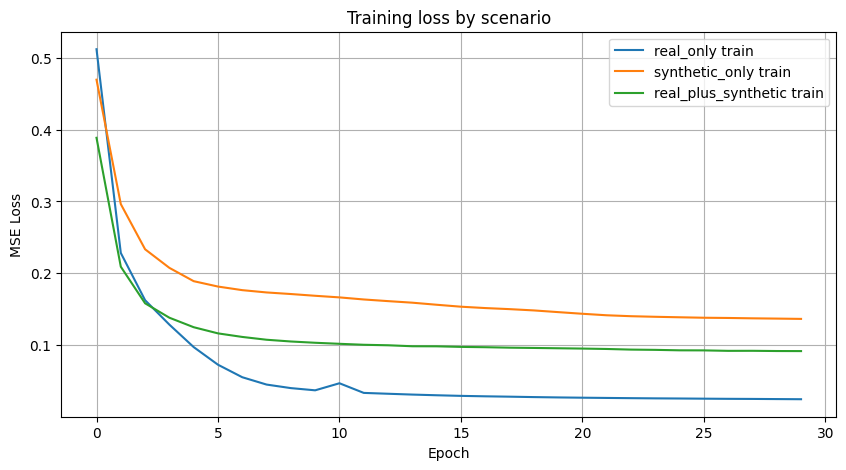

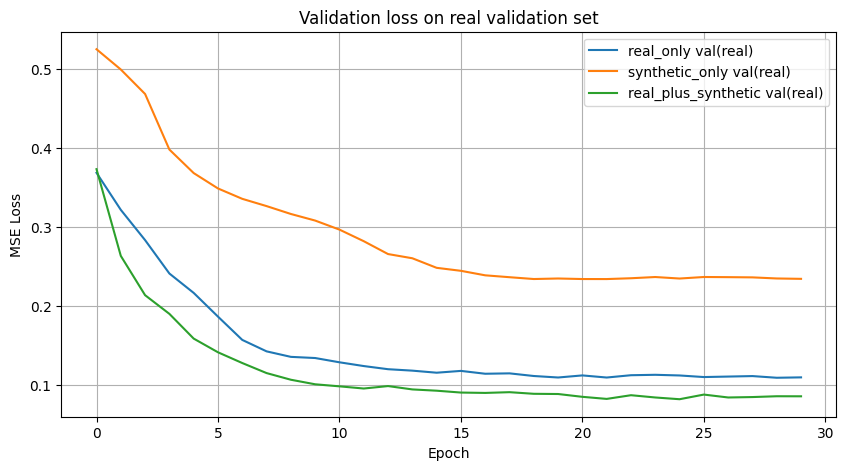

In [19]:
plt.figure(figsize=(10, 5))
for scenario, hist in histories.items():
    plt.plot(hist["train_loss"], label=f"{scenario} train")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training loss by scenario")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
for scenario, hist in histories.items():
    plt.plot(hist["val_loss"], label=f"{scenario} val(real)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Validation loss on real validation set")
plt.legend()
plt.grid(True)
plt.show()


## 13. Distribución de errores


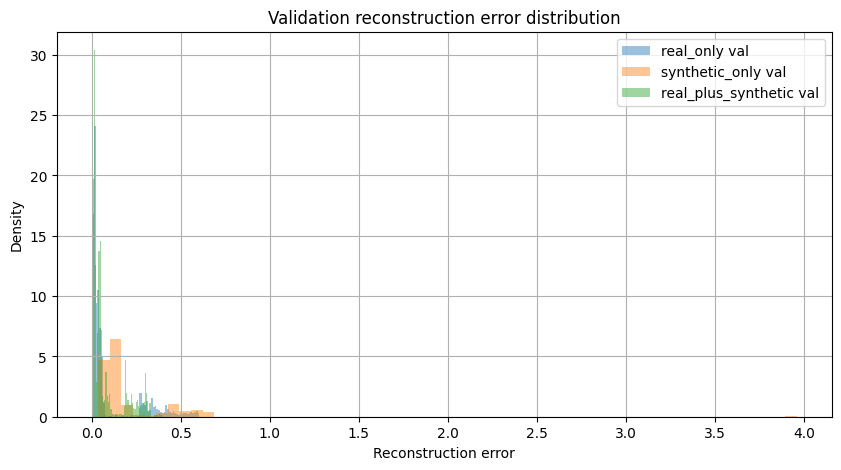

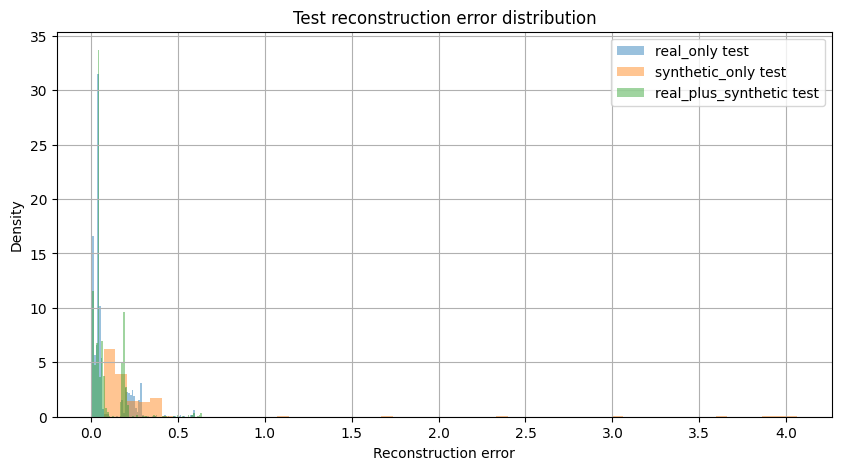

In [20]:
plt.figure(figsize=(10, 5))
for scenario in SCENARIOS:
    plt.hist(all_errors[scenario]["val"], bins=60, alpha=0.45, density=True, label=f"{scenario} val")
plt.xlabel("Reconstruction error")
plt.ylabel("Density")
plt.title("Validation reconstruction error distribution")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
for scenario in SCENARIOS:
    plt.hist(all_errors[scenario]["test"], bins=60, alpha=0.45, density=True, label=f"{scenario} test")
plt.xlabel("Reconstruction error")
plt.ylabel("Density")
plt.title("Test reconstruction error distribution")
plt.legend()
plt.grid(True)
plt.show()


C:\Users\Juan\AppData\Local\Temp\ipykernel_23084\2877114698.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=plot_labels, showfliers=False)


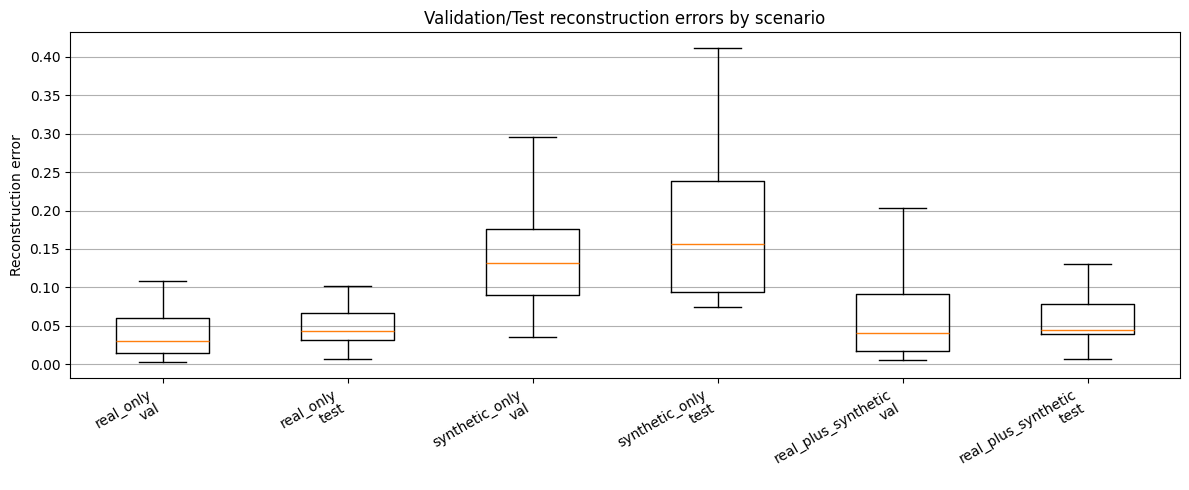

In [21]:
plot_data, plot_labels = [], []
for scenario in SCENARIOS:
    plot_data.append(all_errors[scenario]["val"])
    plot_labels.append(f"{scenario}\nval")
    plot_data.append(all_errors[scenario]["test"])
    plot_labels.append(f"{scenario}\ntest")

plt.figure(figsize=(12, 5))
plt.boxplot(plot_data, labels=plot_labels, showfliers=False)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Reconstruction error")
plt.title("Validation/Test reconstruction errors by scenario")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()


## 14. Curvas ECDF


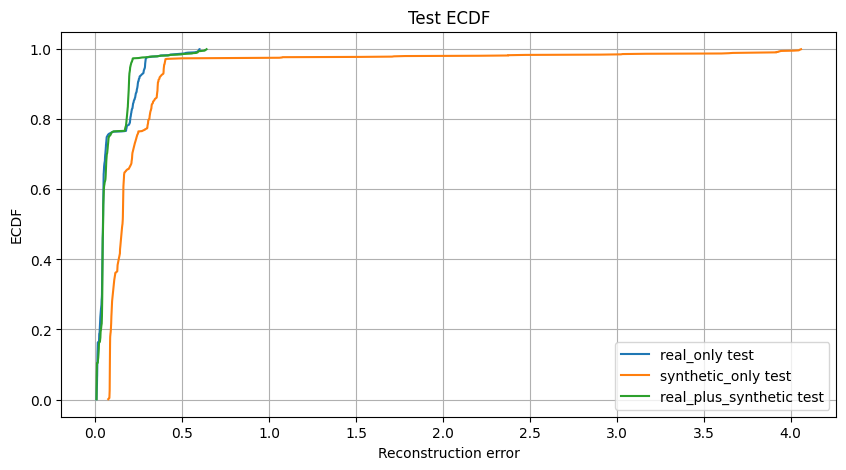

In [22]:
def plot_ecdf(errors, label):
    x = np.sort(errors)
    y = np.arange(1, len(x) + 1) / len(x)
    plt.plot(x, y, label=label)

plt.figure(figsize=(10, 5))
for scenario in SCENARIOS:
    plot_ecdf(all_errors[scenario]["test"], f"{scenario} test")
plt.xlabel("Reconstruction error")
plt.ylabel("ECDF")
plt.title("Test ECDF")
plt.legend()
plt.grid(True)
plt.show()


## 15. FAR interno por escenario


In [23]:
for scenario, far_df in far_tables.items():
    print(f"\n=== {scenario} ===")
    display(far_df)



=== real_only ===


,percentile,tau,FAR_val,FAR_test
0,90.0,0.359960,0.100649,0.020292
1,95.0,0.452665,0.050325,0.014610
2,97.5,0.535307,0.025162,0.009740
3,99.0,0.579608,0.010552,0.008117
4,99.5,0.592278,0.005682,0.005682



=== synthetic_only ===


,percentile,tau,FAR_val,FAR_test
0,90.0,0.498776,0.100649,0.025974
1,95.0,0.587055,0.050325,0.025974
2,97.5,0.648936,0.025162,0.025974
3,99.0,1.725563,0.010552,0.020292
4,99.5,3.738661,0.005682,0.010552



=== real_plus_synthetic ===


,percentile,tau,FAR_val,FAR_test
0,90.0,0.255170,0.100649,0.025162
1,95.0,0.300949,0.050325,0.022727
2,97.5,0.307339,0.025162,0.021916
3,99.0,0.327759,0.010552,0.021104
4,99.5,0.353171,0.005682,0.021104


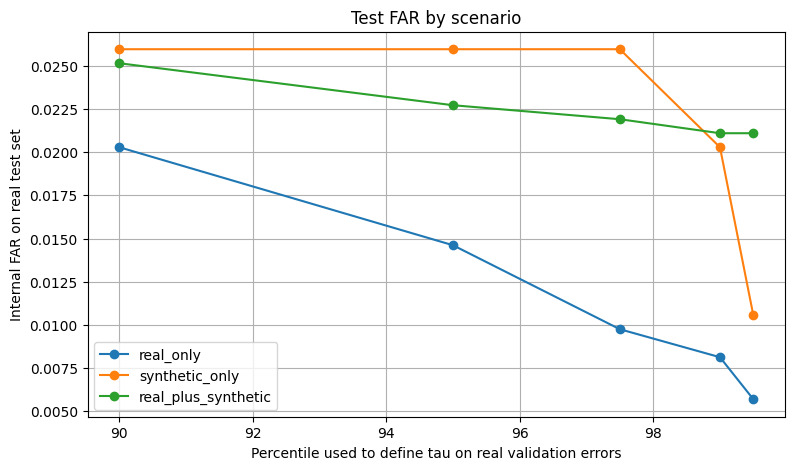

In [24]:
plt.figure(figsize=(9, 5))
for scenario, far_df in far_tables.items():
    plt.plot(far_df["percentile"], far_df["FAR_test"], marker="o", label=scenario)
plt.xlabel("Percentile used to define tau on real validation errors")
plt.ylabel("Internal FAR on real test set")
plt.title("Test FAR by scenario")
plt.legend()
plt.grid(True)
plt.show()


## 16. Umbrales del baseline real_only


In [25]:
baseline_val_errors = all_errors["real_only"]["val"]
percentiles = [90, 95, 97.5, 99, 99.5]
baseline_tau = {p: np.percentile(baseline_val_errors, p) for p in percentiles}

baseline_threshold_rows = []
for scenario in SCENARIOS:
    val_errors = all_errors[scenario]["val"]
    test_errors = all_errors[scenario]["test"]
    for p, tau in baseline_tau.items():
        baseline_threshold_rows.append({
            "scenario": scenario,
            "baseline_percentile": p,
            "baseline_tau": float(tau),
            "FAR_val_using_real_only_tau": far_at_tau(val_errors, tau),
            "FAR_test_using_real_only_tau": far_at_tau(test_errors, tau),
        })

baseline_threshold_df = pd.DataFrame(baseline_threshold_rows)
display(baseline_threshold_df)


,scenario,baseline_percentile,baseline_tau,FAR_val_using_real_only_tau,FAR_test_using_real_only_tau
0,real_only,90.0,0.359960,0.100649,0.020292
1,real_only,95.0,0.452665,0.050325,0.014610
2,real_only,97.5,0.535307,0.025162,0.009740
3,real_only,99.0,0.579608,0.010552,0.008117
4,real_only,99.5,0.592278,0.005682,0.005682
5,synthetic_only,90.0,0.359960,0.195617,0.095779
6,synthetic_only,95.0,0.452665,0.129058,0.027597
7,synthetic_only,97.5,0.535307,0.086039,0.025974
8,synthetic_only,99.0,0.579608,0.053571,0.025974
9,synthetic_only,99.5,0.592278,0.048701,0.025974


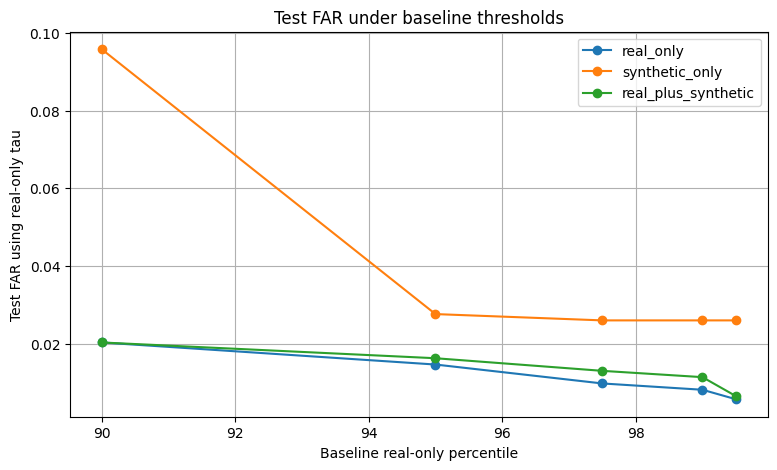

In [26]:
plt.figure(figsize=(9, 5))
for scenario in SCENARIOS:
    df_s = baseline_threshold_df[baseline_threshold_df["scenario"] == scenario]
    plt.plot(df_s["baseline_percentile"], df_s["FAR_test_using_real_only_tau"], marker="o", label=scenario)
plt.xlabel("Baseline real-only percentile")
plt.ylabel("Test FAR using real-only tau")
plt.title("Test FAR under baseline thresholds")
plt.legend()
plt.grid(True)
plt.show()


## 17. Guardado de resultados


In [27]:
RESULTS_DIR = PROJECT_ROOT / "artifacts" / "tstr_internal_validation"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

summary_df.to_csv(RESULTS_DIR / "summary_errors.csv", index=False)
baseline_threshold_df.to_csv(RESULTS_DIR / "baseline_threshold_far.csv", index=False)

for scenario, far_df in far_tables.items():
    far_df.to_csv(RESULTS_DIR / f"far_table_{scenario}.csv", index=False)
    pd.DataFrame(histories[scenario]).to_csv(RESULTS_DIR / f"loss_history_{scenario}.csv", index=False)
    np.save(RESULTS_DIR / f"val_errors_{scenario}.npy", all_errors[scenario]["val"])
    np.save(RESULTS_DIR / f"test_errors_{scenario}.npy", all_errors[scenario]["test"])

config_out = {
    "validation_type": "internal_unsupervised",
    "scenarios": list(SCENARIOS.keys()),
    "window_size": WINDOW_SIZE,
    "stride": STRIDE,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "timegan_model_dir": str(TIMEGAN_MODEL_DIR),
    "match_synth_to_real": MATCH_SYNTH_TO_REAL,
    "x_train_real_shape": list(X_train_real.shape),
    "x_train_synth_used_shape": list(X_train_synth_used.shape),
    "x_train_mixed_shape": list(X_train_mixed.shape),
    "x_val_real_shape": list(X_val_real.shape),
    "x_test_real_shape": list(X_test_real.shape),
}

with open(RESULTS_DIR / "config.json", "w") as f:
    json.dump(config_out, f, indent=4)

print("Resultados guardados en:", RESULTS_DIR.resolve())


Resultados guardados en: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\artifacts\tstr_internal_validation


## 18. Lectura de resultados

Esta validación es interna y no supervisada. Por tanto, no busca medir detección de anomalías etiquetadas todavía.

Interpretación sugerida:

- Si `synthetic_only` reconstruye mal validación/test real, entonces los sintéticos no bastan para entrenar solos el detector.
- Si `real_plus_synthetic` mantiene o reduce error/FAR frente a `real_only`, entonces los sintéticos están aportando regularización o cobertura útil.
- Si `real_plus_synthetic` empeora mucho, los sintéticos pueden estar desplazando la distribución de entrenamiento.

La validación externa posterior debe usar labels de anomalía y comparar métricas supervisadas.
